**Customer Retention Enhancement through Predictive Analytics-Lloyds Banking Group**

**Smart Bank** is facing increasing customer churn - especially in **young professsionals and small business owners**. This is leading to revenue loss, reduced markey share and long-term business problems. 

So the main objective here is to build a predictive system that can identify customers who are at risk of churning and help the bank take targeted actions to retain them

**STEP-1** - Import the required libraries

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**STEP-2** - Load the Excel file

In [3]:
%pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [117]:
file_path = "Customer_Churn_Data_Large.xlsx"

demographics = pd.read_excel(file_path, sheet_name="Customer_Demographics")
transactions = pd.read_excel(file_path, sheet_name="Transaction_History")
service = pd.read_excel(file_path, sheet_name="Customer_Service")
online = pd.read_excel(file_path, sheet_name="Online_Activity")
churn = pd.read_excel(file_path, sheet_name="Churn_Status")

In [118]:
demographics.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


In [119]:
transactions.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing


In [120]:
service.head()

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved
2,3,9976,2022-08-24,Inquiry,Resolved
3,4,7354,2022-11-18,Inquiry,Resolved
4,4,5393,2022-07-03,Inquiry,Unresolved


In [121]:
online.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
0,1,2023-10-21,34,Mobile App
1,2,2023-12-05,5,Website
2,3,2023-11-15,3,Website
3,4,2023-08-25,2,Website
4,5,2023-10-27,41,Website


In [122]:
churn.head()

,CustomerID,ChurnStatus
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


In [123]:
print(demographics.shape)
print(transactions.shape)
print(service.shape)
print(online.shape)
print(churn.shape)

(1000, 5)
(5054, 5)
(1002, 5)
(1000, 4)
(1000, 2)


In [124]:
print(demographics.info())
print(transactions.info())
print(service.info())
print(online.info())
print(churn.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   int64 
 1   Age            1000 non-null   int64 
 2   Gender         1000 non-null   object
 3   MaritalStatus  1000 non-null   object
 4   IncomeLevel    1000 non-null   object
dtypes: int64(2), object(3)
memory usage: 39.2+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5054 entries, 0 to 5053
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CustomerID       5054 non-null   int64         
 1   TransactionID    5054 non-null   int64         
 2   TransactionDate  5054 non-null   datetime64[ns]
 3   AmountSpent      5054 non-null   float64       
 4   ProductCategory  5054 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
me

In [125]:
print(demographics.isnull().sum())
print(transactions.isnull().sum())
print(service.isnull().sum())
print(online.isnull().sum())
print(churn.isnull().sum())

CustomerID       0
Age              0
Gender           0
MaritalStatus    0
IncomeLevel      0
dtype: int64
CustomerID         0
TransactionID      0
TransactionDate    0
AmountSpent        0
ProductCategory    0
dtype: int64
CustomerID          0
InteractionID       0
InteractionDate     0
InteractionType     0
ResolutionStatus    0
dtype: int64
CustomerID        0
LastLoginDate     0
LoginFrequency    0
ServiceUsage      0
dtype: int64
CustomerID     0
ChurnStatus    0
dtype: int64


The dataset used for this customer churn analysis is stored in a single Excel file containing multiple sheets. Each sheet represents a different aspect of customer behaviour and interactions with the bank. These datasets together provide a comprehensive view of customer profiles, activity patterns, and engagement levels, which are important factors for predicting customer churn.

The Excel file contains five datasets:

1. **Customer Demographics** - This dataset contains basic customer information such as:

* CustomerID
* Age
* Gender
* MaritalStatus
* IncomeLevel

These variables help understand customer background characteristics that may influence churn behaviour.

2.**Transaction History -** This dataset records customer purchase and spending activity, including:

* CustomerID
* TransactionID
* TransactionDate
* AmountSpent
* ProductCategory

Transaction behaviour can provide insights into customer engagement and purchasing patterns.

3. **Customer Service Interactions**- This dataset captures interactions between customers and the bank’s support services:

* CustomerID
* InteractionID
* InteractionDate
* InteractionType
* ResolutionStatus

Frequent support interactions or unresolved issues may indicate dissatisfaction and increase churn risk.

4. **Online Activity** - This dataset contains information about customers’ digital engagement:

* CustomerID
* LastLoginDate
* LoginFrequency
* ServiceUsage

Online banking behaviour is an important indicator of how actively customers use banking services.

5. **Churn Status -** This dataset provides the target variable for the analysis:

* CustomerID
* ChurnStatus

The churn status indicates whether a customer has left the bank or remained active.

Since CustomerID is present in all datasets, it acts as the primary key that can be used to link the datasets together for integrated analysis.

In this stage, each sheet will be loaded into separate dataframes using Python’s pandas library. The datasets will then be inspected to understand their structure, data types, and potential data quality issues before proceeding with exploratory data analysis and preprocessing.

In [126]:
print(demographics['CustomerID'].nunique())
print(transactions['CustomerID'].nunique())
print(service['CustomerID'].nunique())
print(online['CustomerID'].nunique())
print(churn['CustomerID'].nunique())

1000
1000
668
1000
1000


**Feature Engineering and Dataset Integration**

Before merging the datasets, it is important to transform transactional datasets into customer-level features. Some datasets such as transaction history and customer service interactions contain multiple records for each customer. Directly merging these datasets would result in duplicate rows for customers.

To avoid this issue, the datasets are first aggregated to extract meaningful customer-level behavioural features.

**STEP-1** - transaction feature engineering

For the transaction history dataset, features such as the total number of transactions, total amount spent, average transaction value, and the distribution of product categories are computed. These metrics capture customer spending behaviour and engagement with different product categories.

In [127]:
transaction_features = transactions.groupby("CustomerID").agg(
    TotalTransactions=("TransactionID", "count"),
    TotalSpent=("AmountSpent", "sum"),
    AvgTransactionValue=("AmountSpent", "mean")
).reset_index()

In [128]:
product_category_features = pd.crosstab(
    transactions["CustomerID"],
    transactions["ProductCategory"]
).reset_index()

In [129]:
transaction_features = transaction_features.merge(
    product_category_features,
    on="CustomerID",
    how="left"
)

**Step 2 — Customer Service Feature Engineering** - For the customer service dataset, interaction frequency, interaction types, and resolution outcomes are summarised to capture customer support behaviour and potential dissatisfaction.

In [130]:
interaction_features = service.groupby("CustomerID").agg(
    TotalInteractions=("InteractionID", "count")
).reset_index()

In [131]:
interaction_type_features = pd.crosstab(
    service["CustomerID"],
    service["InteractionType"]
).reset_index()

In [132]:
resolution_features = pd.crosstab(
    service["CustomerID"],
    service["ResolutionStatus"]
).reset_index()

In [133]:
service_features = interaction_features.merge(
    interaction_type_features,
    on="CustomerID",
    how="left"
)

service_features = service_features.merge(
    resolution_features,
    on="CustomerID",
    how="left"
)

**STEP-3** - merge the datasets

The online activity dataset already contains one record per customer and can therefore be merged directly.

All datasets are merged using CustomerID as the primary key to produce a unified dataset that combines customer demographics, behavioural patterns, service interactions, and churn status. This consolidated dataset provides a comprehensive view of each customer and forms the foundation for exploratory analysis and predictive modelling.

In [134]:
merged_df = demographics.merge(churn, on="CustomerID", how="left")

In [135]:
merged_df = merged_df.merge(online, on="CustomerID", how="left")

In [136]:
merged_df = merged_df.merge(transaction_features, on="CustomerID", how="left")

In [ ]:
merged_df = merged_df.merge(service_features, on="CustomerID", how="left")

In [138]:
merged_df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,ChurnStatus,LastLoginDate,LoginFrequency,ServiceUsage,TotalTransactions,...,Clothing,Electronics,Furniture,Groceries,TotalInteractions,Complaint,Feedback,Inquiry,Resolved,Unresolved
0,1,62,M,Single,Low,0,2023-10-21,34,Mobile App,1,...,0,1,0,0,1.0,0.0,0.0,1.0,1.0,0.0
1,2,65,M,Married,Low,1,2023-12-05,5,Website,7,...,2,3,1,1,1.0,0.0,0.0,1.0,1.0,0.0
2,3,18,M,Single,Low,0,2023-11-15,3,Website,6,...,1,0,2,2,1.0,0.0,0.0,1.0,1.0,0.0
3,4,21,M,Widowed,Low,0,2023-08-25,2,Website,5,...,1,2,1,1,2.0,0.0,0.0,2.0,1.0,1.0
4,5,21,M,Divorced,Medium,0,2023-10-27,41,Website,8,...,0,3,2,3,NaN,NaN,NaN,NaN,NaN,NaN


In [139]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           1000 non-null   int64         
 1   Age                  1000 non-null   int64         
 2   Gender               1000 non-null   object        
 3   MaritalStatus        1000 non-null   object        
 4   IncomeLevel          1000 non-null   object        
 5   ChurnStatus          1000 non-null   int64         
 6   LastLoginDate        1000 non-null   datetime64[ns]
 7   LoginFrequency       1000 non-null   int64         
 8   ServiceUsage         1000 non-null   object        
 9   TotalTransactions    1000 non-null   int64         
 10  TotalSpent           1000 non-null   float64       
 11  AvgTransactionValue  1000 non-null   float64       
 12  Books                1000 non-null   int64         
 13  Clothing             1000 non-null

**Handling the missing values**

Customers who never interacted with service or made transactions may have missing values.

In [140]:
merged_df.fillna(0, inplace=True)

Save the combined dataset

In [141]:
merged_df.to_csv("merged_customer_data.csv", index=False)

**Univariate Analysis**

Univariate analysis focuses on examining one variable at a time to understand its distribution, central tendency, spread, and overall characteristics. This step helps identify patterns, potential outliers, and data imbalances before exploring relationships between variables.

In this stage, we analyse both numerical and categorical variables individually using statistical summaries and visualisations. Numerical features are analysed using histograms, boxplots, and density plots to understand their distribution and variability. Categorical variables are analysed using bar charts and count plots to examine the frequency of each category.

Understanding these individual feature distributions provides a foundation for further analysis and helps identify variables that may influence customer churn.

In [142]:
#identify the variable types
num_cols = merged_df.select_dtypes(include=['int64','float64']).columns
cat_cols = merged_df.select_dtypes(include=['object']).columns
num_cols = [col for col in num_cols if col != 'CustomerID']

In [143]:
#Summary Stats
merged_df[num_cols].describe()

,Age,ChurnStatus,LoginFrequency,TotalTransactions,TotalSpent,AvgTransactionValue,Books,Clothing,Electronics,Furniture,Groceries,TotalInteractions,Complaint,Feedback,Inquiry,Resolved,Unresolved
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,43.267000,0.204000,25.912000,5.054000,1267.074950,248.806511,1.041000,1.000000,1.001000,0.992000,1.020000,1.002000,0.335000,0.36000,0.307000,0.523000,0.479000
std,15.242311,0.403171,14.055953,2.603433,738.590013,79.372766,1.032659,1.026184,1.048856,1.007448,1.022079,0.816494,0.546877,0.58029,0.518671,0.632353,0.621245
min,18.000000,0.000000,1.000000,1.000000,9.800000,9.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,13.750000,3.000000,626.685000,203.734167,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,43.000000,0.000000,27.000000,5.000000,1232.880000,250.121458,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,56.000000,0.000000,38.000000,7.000000,1791.902500,295.023854,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.00000,1.000000,1.000000,1.000000
max,69.000000,1.000000,49.000000,9.000000,3386.040000,496.990000,6.000000,6.000000,6.000000,6.000000,4.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000


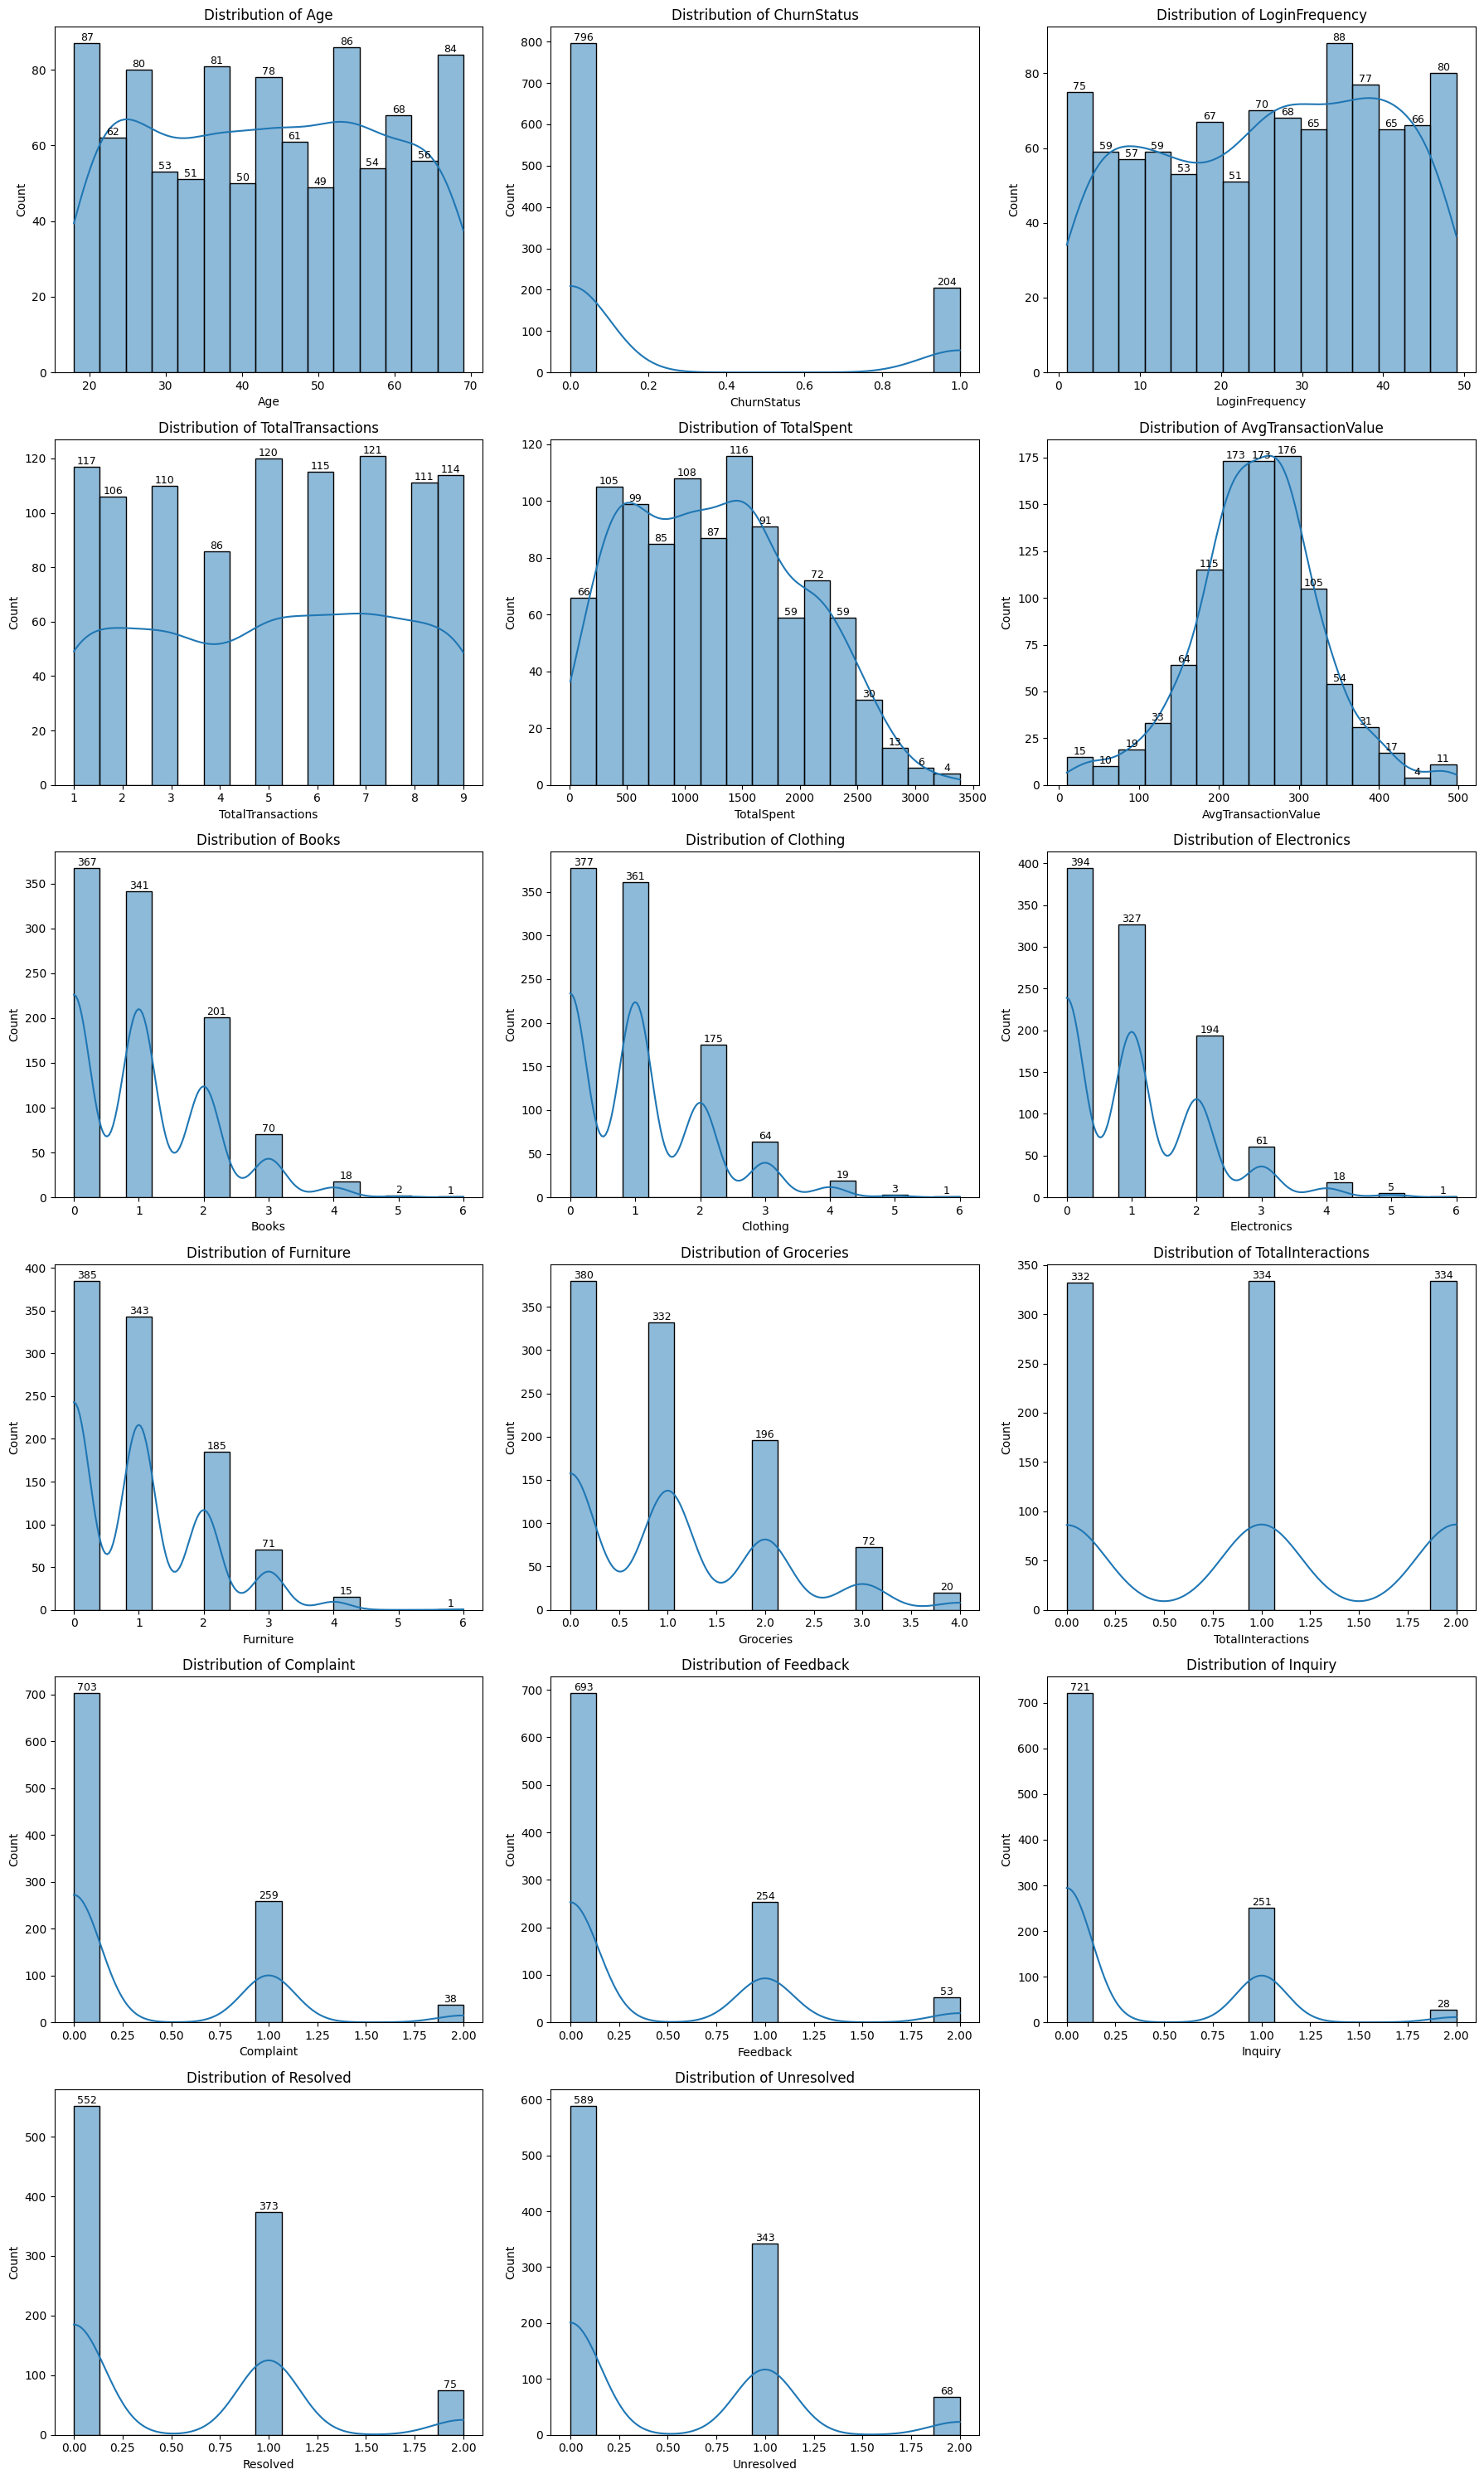

In [144]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18,5*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    
    ax = sns.histplot(merged_df[col], kde=True, bins=15, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    
    # Add numbers on top of histogram bars
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:
            ax.text(
                patch.get_x() + patch.get_width()/2,
                height,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontsize=9
            )

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

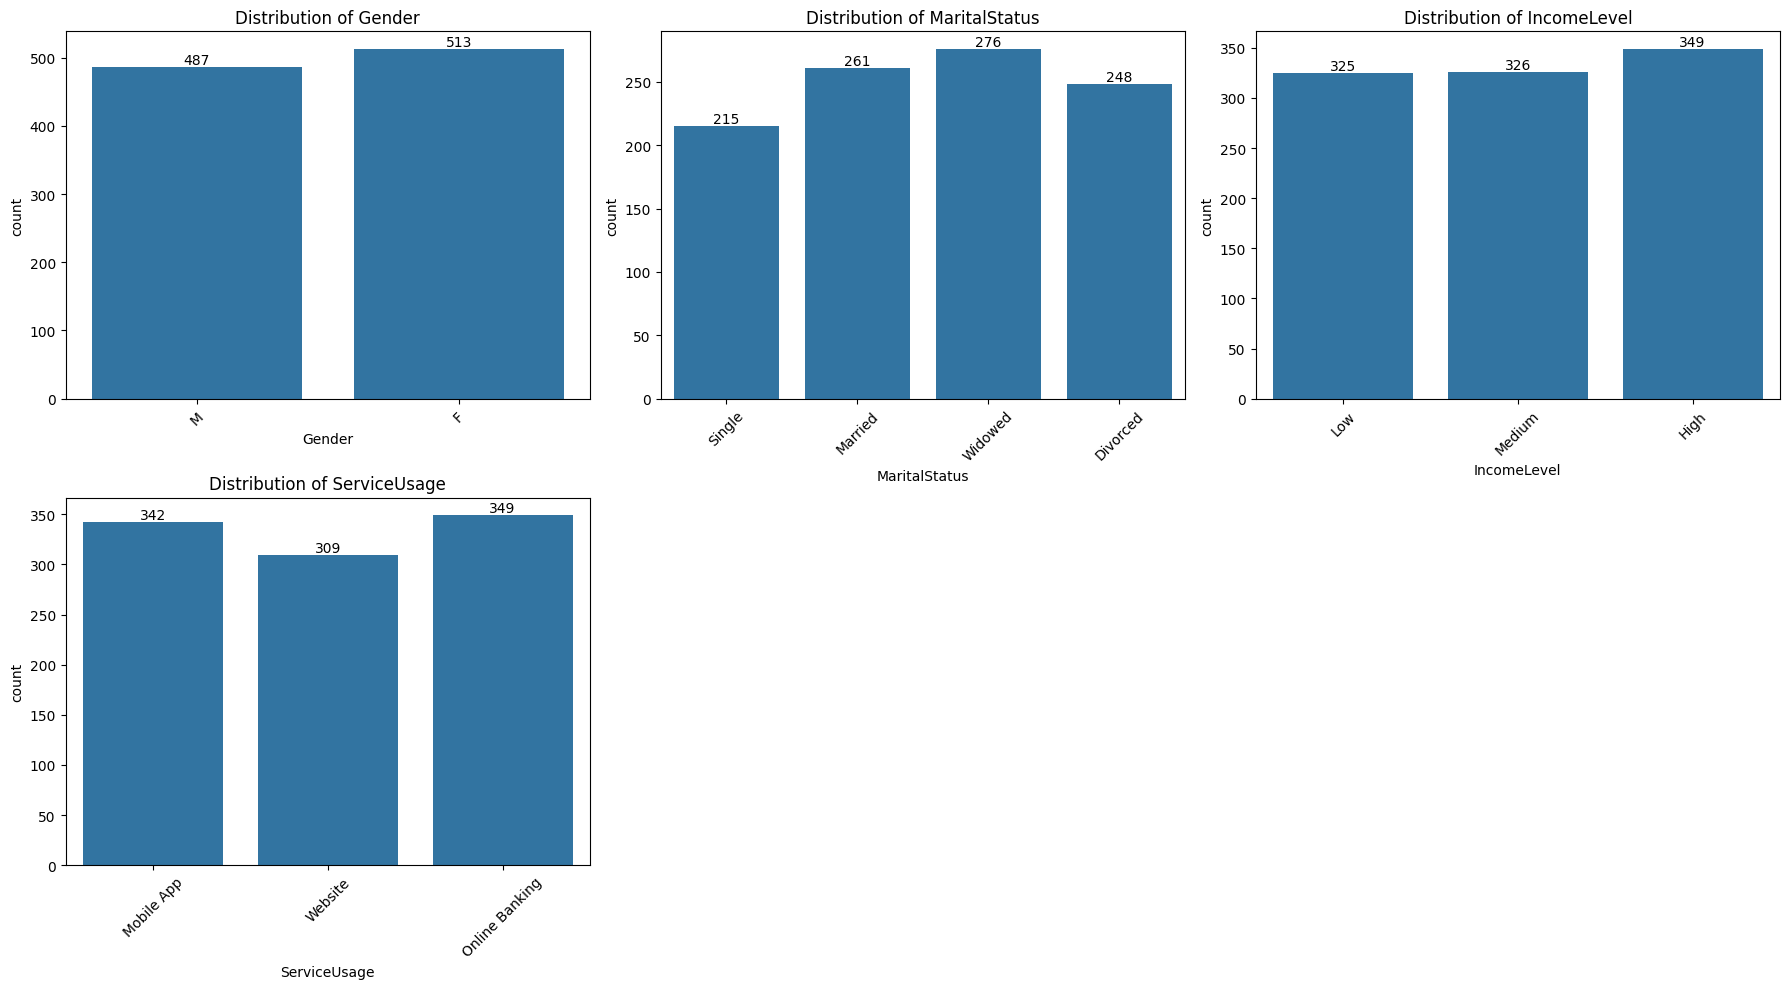

In [102]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18,5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):

    ax = sns.countplot(data=merged_df, x=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

    # Add values on top of bars
    for container in ax.containers:
        ax.bar_label(container)

# Remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

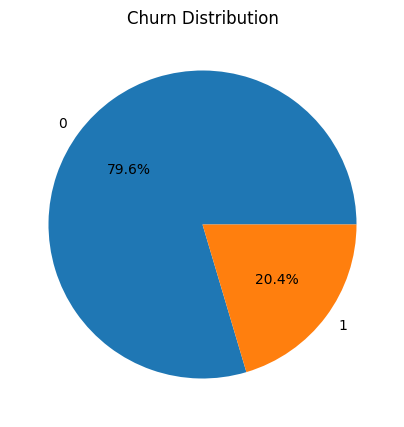

In [146]:
merged_df['ChurnStatus'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(5,5),
    title="Churn Distribution"
)
plt.ylabel("")
plt.show()

In [96]:
merged_df[num_cols].skew()

CustomerID           0.000000
Age                  0.013168
ChurnStatus          1.471304
LoginFrequency      -0.127877
TotalInteractions   -0.003678
Complaint            1.380639
Feedback             1.375799
Inquiry              1.427210
Resolved             0.805922
Unresolved           0.933076
dtype: float64

"The data reveals a 'Digital Engagement Gap.' While Smart Bank has a strong base of young professionals using the Mobile App, the high volume of Unresolved Complaints and the 20.4% baseline churn suggest that transactional friction is outweighing digital convenience. We should focus the predictive model on customers whose Total Interactions are high but Total Spent is declining, as this indicates a customer who is still 'looking' at the bank but moving their money out."

**Bivariate Analysis**

Bivariate analysis examines the relationship between two variables to understand how one variable may influence another. In this project, the primary objective is to analyse how different customer attributes and behavioural patterns relate to customer churn.

By comparing customer demographics, transaction behaviour, service interactions, and digital engagement with churn status, we can identify key patterns and potential predictors of churn.

The insights derived from this analysis will help determine which features are most important for building an effective churn prediction model.

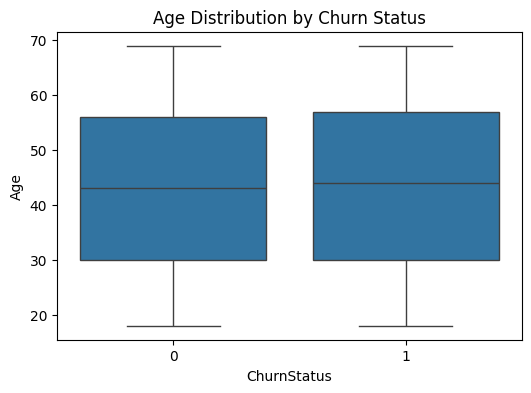

In [148]:
#Age vs churn 

plt.figure(figsize=(6,4))
sns.boxplot(data=merged_df, x='ChurnStatus', y='Age')

plt.title("Age Distribution by Churn Status")
plt.show()

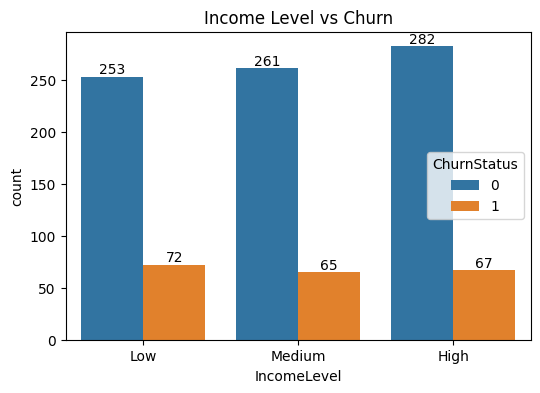

In [106]:
#income vs churn
plt.figure(figsize=(6,4))

ax = sns.countplot(data=merged_df, x='IncomeLevel', hue='ChurnStatus')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Income Level vs Churn")
plt.show()

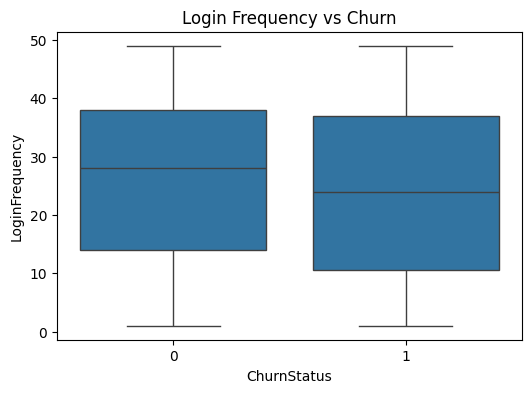

In [107]:
#loging frequency vs churn - 
plt.figure(figsize=(6,4))

sns.boxplot(data=merged_df, x='ChurnStatus', y='LoginFrequency')

plt.title("Login Frequency vs Churn")
plt.show()

In [109]:
merged_df.columns

Index(['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'IncomeLevel',
       'ChurnStatus', 'LastLoginDate', 'LoginFrequency', 'ServiceUsage',
       'TotalInteractions', 'Complaint', 'Feedback', 'Inquiry', 'Resolved',
       'Unresolved'],
      dtype='object')

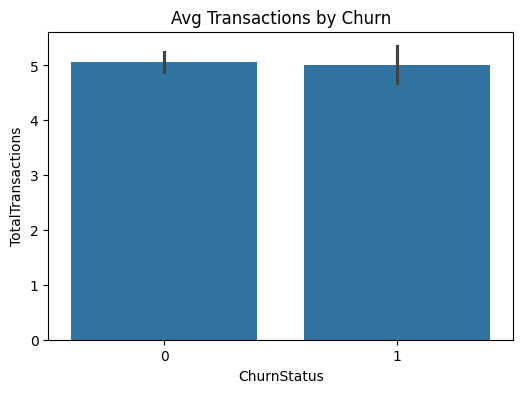

In [151]:
#Total transactions vs churn 
plt.figure(figsize=(6,4))

sns.barplot(data=merged_df, x='ChurnStatus', y='TotalTransactions')

plt.title("Avg Transactions by Churn")
plt.show()

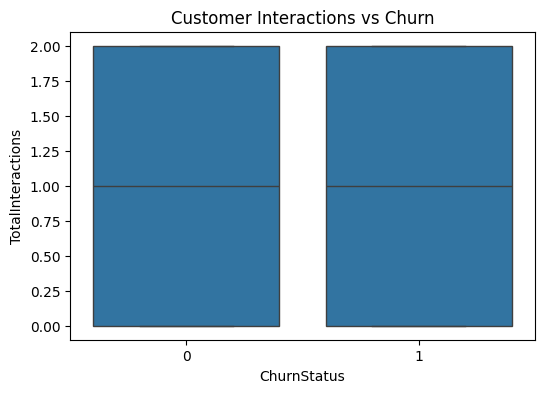

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(data=merged_df, x='ChurnStatus', y='TotalInteractions')

plt.title("Customer Interactions vs Churn")
plt.show()

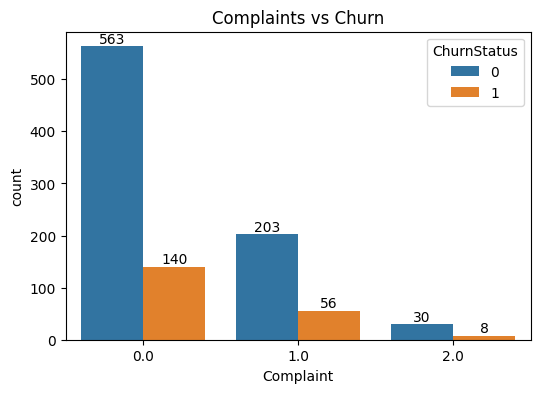

In [111]:
#complaints vs churn
plt.figure(figsize=(6,4))

ax = sns.countplot(data=merged_df, x='Complaint', hue='ChurnStatus')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Complaints vs Churn")
plt.show()

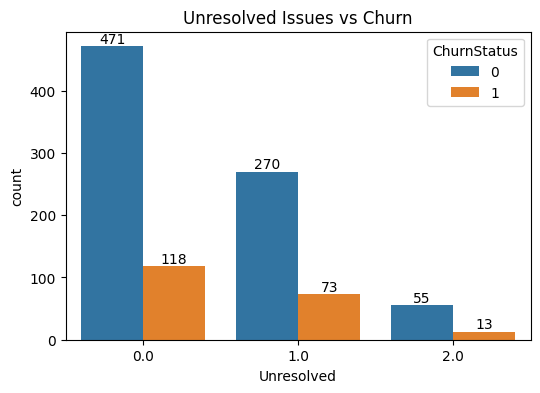

In [112]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=merged_df, x='Unresolved', hue='ChurnStatus')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Unresolved Issues vs Churn")
plt.show()

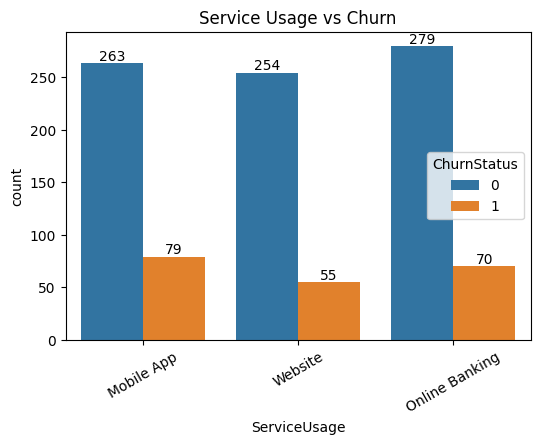

In [113]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=merged_df, x='ServiceUsage', hue='ChurnStatus')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Service Usage vs Churn")
plt.xticks(rotation=30)
plt.show()

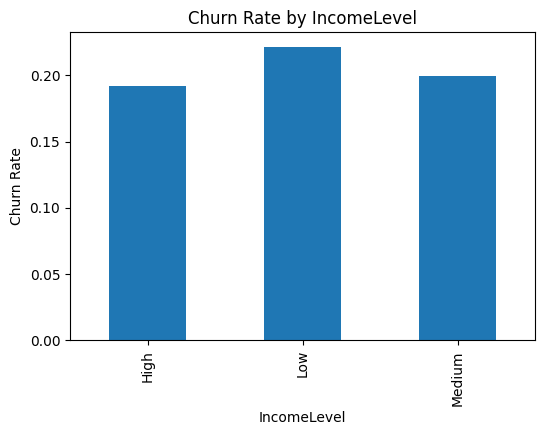

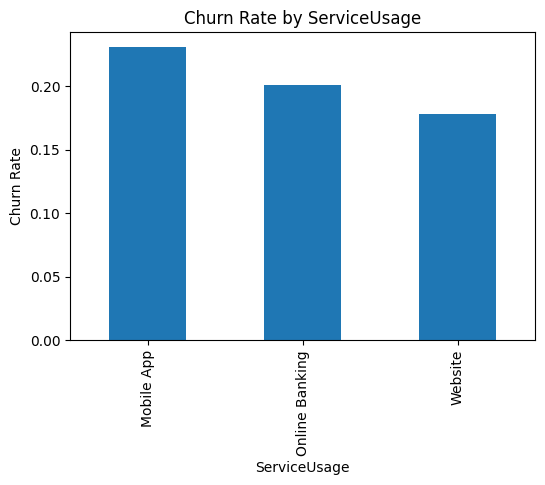

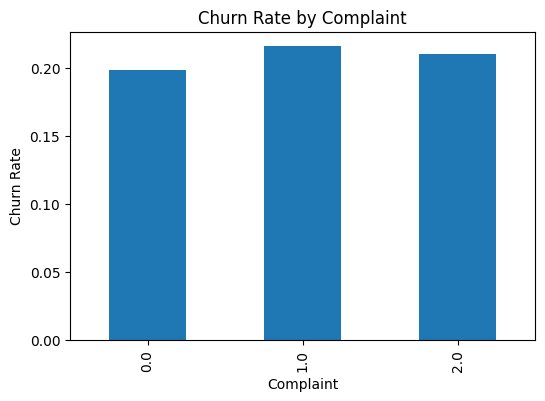

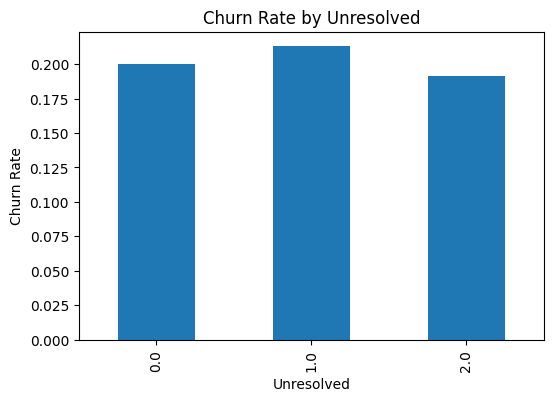

In [153]:
features = ['IncomeLevel', 'ServiceUsage', 'Complaint', 'Unresolved']

for col in features:
    churn_rate = merged_df.groupby(col)['ChurnStatus'].mean()
    
    churn_rate.plot(kind='bar', figsize=(6,4))
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.show()

In [155]:
merged_df.corr(numeric_only=True)['ChurnStatus'].sort_values(ascending=False)

ChurnStatus            1.000000
Electronics            0.049228
AvgTransactionValue    0.044811
Age                    0.029407
Furniture              0.026202
Complaint              0.016616
Feedback               0.010953
Unresolved             0.005132
TotalInteractions      0.004841
TotalSpent             0.001324
Resolved               0.001209
TotalTransactions     -0.008598
CustomerID            -0.011528
Groceries             -0.019628
Inquiry               -0.022154
Books                 -0.036940
Clothing              -0.041131
LoginFrequency        -0.081615
Name: ChurnStatus, dtype: float64

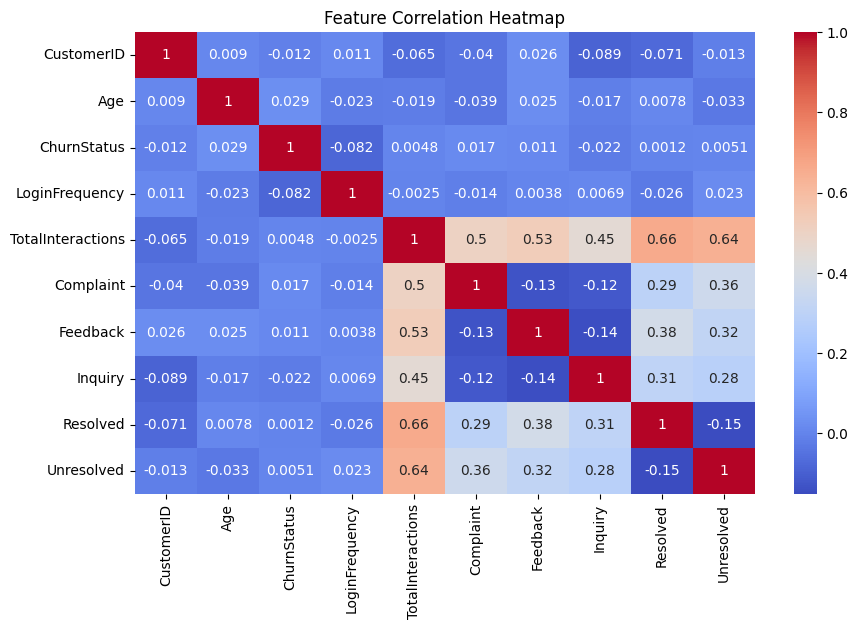

In [115]:
plt.figure(figsize=(10,6))

sns.heatmap(
    merged_df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")
plt.show()

Cleaning and Preprocessing

In [156]:
df = merged_df.copy()

#dropping the irrelevant cols
df.drop(columns=['CustomerID'], inplace=True, errors='ignore')

In [157]:
#handling missing vals
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill numerical with 0
df[num_cols] = df[num_cols].fillna(0)

# Fill categorical with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\Shivani\AppData\Local\Temp\ipykernel_9780\1319600663.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Encoding - label encoder

In [160]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

Split the dataset

In [161]:
from sklearn.model_selection import train_test_split

X = df.drop('ChurnStatus', axis=1)
y = df['ChurnStatus']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

Feature Scaling

In [163]:
# Convert to datetime (if not already)
date_cols = X_train.select_dtypes(include=['datetime64[ns]']).columns

for col in date_cols:
    X_train[col] = pd.to_datetime(X_train[col], errors='coerce')
    X_test[col] = pd.to_datetime(X_test[col], errors='coerce')

    # Extract useful features
    X_train[col + '_year'] = X_train[col].dt.year
    X_train[col + '_month'] = X_train[col].dt.month
    X_train[col + '_day'] = X_train[col].dt.day

    X_test[col + '_year'] = X_test[col].dt.year
    X_test[col + '_month'] = X_test[col].dt.month
    X_test[col + '_day'] = X_test[col].dt.day

# Drop original date columns
X_train.drop(columns=date_cols, inplace=True)
X_test.drop(columns=date_cols, inplace=True)

In [164]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


SMOTE - Handle Imbalance

In [165]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)


# Final data ready for modeling
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: ChurnStatus
0    637
1    163
Name: count, dtype: int64
After SMOTE: ChurnStatus
0    637
1    637
Name: count, dtype: int64


Model Building and training 

In [171]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression
[[81 78]
 [16 25]]
              precision    recall  f1-score   support

           0       0.84      0.51      0.63       159
           1       0.24      0.61      0.35        41

    accuracy                           0.53       200
   macro avg       0.54      0.56      0.49       200
weighted avg       0.71      0.53      0.57       200

ROC-AUC: 0.5743212149102623


In [173]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:,1]

print("Random Forest")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest
[[152   7]
 [ 40   1]]
              precision    recall  f1-score   support

           0       0.79      0.96      0.87       159
           1       0.12      0.02      0.04        41

    accuracy                           0.77       200
   macro avg       0.46      0.49      0.45       200
weighted avg       0.66      0.77      0.70       200

ROC-AUC: 0.5647338548857186


In [174]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:,1]

print("Gradient Boosting")
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

Gradient Boosting
[[149  10]
 [ 38   3]]
              precision    recall  f1-score   support

           0       0.80      0.94      0.86       159
           1       0.23      0.07      0.11        41

    accuracy                           0.76       200
   macro avg       0.51      0.51      0.49       200
weighted avg       0.68      0.76      0.71       200

ROC-AUC: 0.49286700414173956


In [175]:
from sklearn.metrics import classification_report, roc_auc_score

def evaluate_model(name, y_test, y_pred, y_prob):
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)
evaluate_model("Gradient Boosting", y_test, y_pred_gb, y_prob_gb)


Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.51      0.63       159
           1       0.24      0.61      0.35        41

    accuracy                           0.53       200
   macro avg       0.54      0.56      0.49       200
weighted avg       0.71      0.53      0.57       200

ROC-AUC: 0.5743212149102623

Random Forest
              precision    recall  f1-score   support

           0       0.79      0.96      0.87       159
           1       0.12      0.02      0.04        41

    accuracy                           0.77       200
   macro avg       0.46      0.49      0.45       200
weighted avg       0.66      0.77      0.70       200

ROC-AUC: 0.5647338548857186

Gradient Boosting
              precision    recall  f1-score   support

           0       0.80      0.94      0.86       159
           1       0.23      0.07      0.11        41

    accuracy                           0.76       200
   macro avg     

In [176]:
from sklearn.model_selection import GridSearchCV

param_lr = {
    'C': [0.01, 0.1, 1, 10]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_lr,
    cv=5,
    scoring='recall'
)

grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_

In [177]:
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_rf,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

In [178]:
param_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(),
    param_gb,
    cv=5,
    scoring='recall'
)

grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_

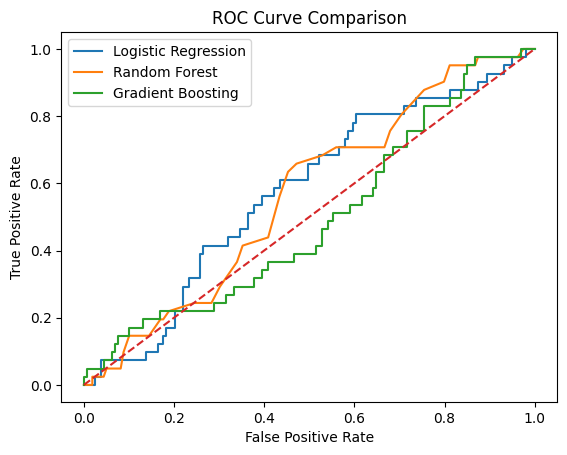

In [179]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

def plot_roc(y_test, y_prob, label):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=label)

plt.figure()

plot_roc(y_test, y_prob_lr, "Logistic Regression")
plot_roc(y_test, y_prob_rf, "Random Forest")
plot_roc(y_test, y_prob_gb, "Gradient Boosting")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [180]:
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.1)

for t in thresholds:
    y_pred_custom = (y_prob_lr > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_custom))


Threshold: 0.1
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       159
           1       0.20      1.00      0.34        41

    accuracy                           0.20       200
   macro avg       0.10      0.50      0.17       200
weighted avg       0.04      0.20      0.07       200


Threshold: 0.2
              precision    recall  f1-score   support

           0       1.00      0.01      0.01       159
           1       0.21      1.00      0.34        41

    accuracy                           0.21       200
   macro avg       0.60      0.50      0.18       200
weighted avg       0.84      0.21      0.08       200


Threshold: 0.30000000000000004
              precision    recall  f1-score   support

           0       0.82      0.06      0.11       159
           1       0.21      0.95      0.34        41

    accuracy                           0.24       200
   macro avg       0.51      0.50      0.22       200
weighted a

C:\Users\Shivani\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Shivani\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Shivani\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz